# Lamar River 7-Day Streamflow Forecasting (Stage 1)

**Implementation of Deep Learning LSTM model following framework.md specifications**

## Objective
Develop a Deep Learning model (LSTM) capable of forecasting the daily mean streamflow of the Lamar River for a **7-day horizon**.

## Stage 1 Approach
- **Endogenous variables**: Past flow only (no climate variables yet)
- **Seasonality**: Cyclical features (sin/cos of day of year)
- **Architecture**: Sequence-to-vector LSTM
- **Lookback**: 60 days
- **Horizon**: 7 days

## Data Source
- **Location**: Lamar River near Tower Falls, WY
- **USGS Site**: 06191500
- **Period**: 1998-2025 (daily data)
- **Training**: 1990-2018
- **Testing**: 2019-present

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Using device: cuda
GPU: NVIDIA GeForce GTX 1070


## 1. Data Loading and Exploration

Dataset loaded: 10,063 daily records
Date range: 1998-01-01 00:00:00+00:00 to 2025-11-20 00:00:00+00:00
Duration: 27.9 years

Streamflow statistics (cfs):
count    10063.000000
mean       925.550084
std       1712.684554
min         40.000000
25%        134.000000
50%        199.000000
75%        661.000000
max      23800.000000
Name: streamflow_cfs, dtype: float64


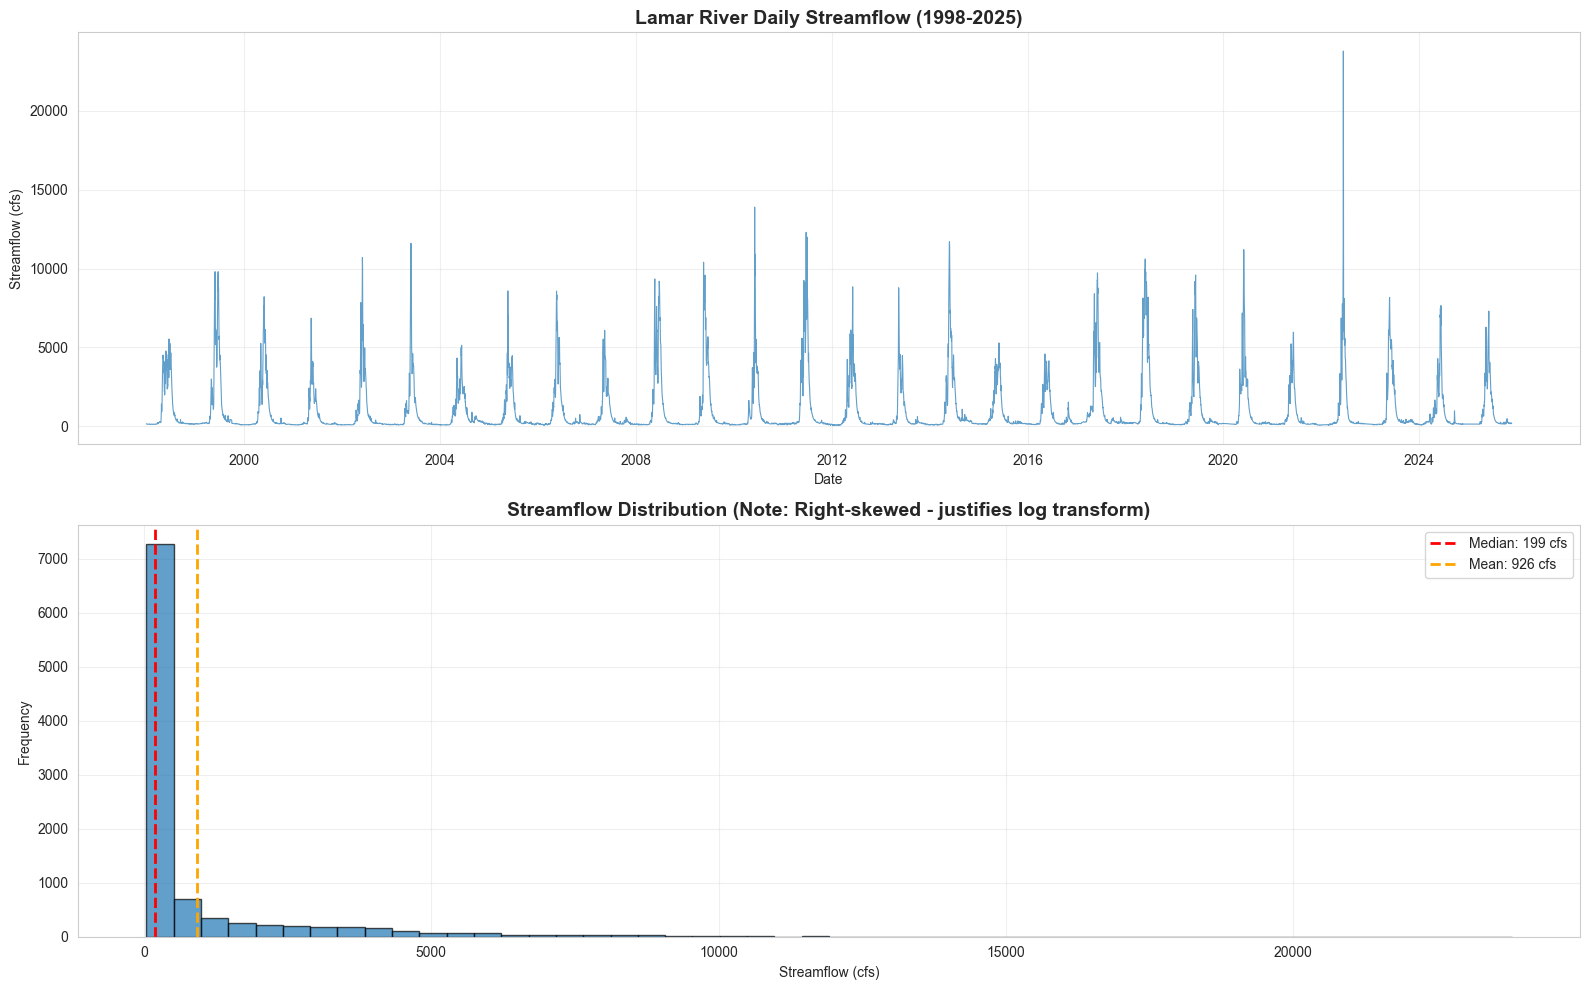


✓ Data filtered to 1998-01-01 onwards for consistency with climate data
✓ Data shows strong seasonality (snowmelt-dominated)
✓ Distribution is right-skewed (peak flows >> base flows)
✓ Log transform will normalize this distribution


In [2]:
# Load daily streamflow data
df = pd.read_csv('../data/lamar_river_streamflow.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Filter to dates >= 1998-01-01 for consistency with climate data
df = df[df['date'] >= '1998-01-01'].copy()
df = df.reset_index(drop=True)

print(f"Dataset loaded: {len(df):,} daily records")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Duration: {(df['date'].max() - df['date'].min()).days / 365.25:.1f} years")

print(f"\nStreamflow statistics (cfs):")
print(df['streamflow_cfs'].describe())

# Visualize full time series
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df['date'], df['streamflow_cfs'], linewidth=0.8, alpha=0.7)
axes[0].set_title('Lamar River Daily Streamflow (1998-2025)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Streamflow (cfs)')
axes[0].grid(True, alpha=0.3)

# Distribution
axes[1].hist(df['streamflow_cfs'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Streamflow Distribution (Note: Right-skewed - justifies log transform)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Streamflow (cfs)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['streamflow_cfs'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["streamflow_cfs"].median():.0f} cfs')
axes[1].axvline(df['streamflow_cfs'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {df["streamflow_cfs"].mean():.0f} cfs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Data filtered to 1998-01-01 onwards for consistency with climate data")
print(f"✓ Data shows strong seasonality (snowmelt-dominated)")
print(f"✓ Distribution is right-skewed (peak flows >> base flows)")
print(f"✓ Log transform will normalize this distribution")

## 2. Feature Engineering (per framework.md specification)

### Feature Transformations:
1. **Log-transform**: $y = \log(Q + 1)$ to normalize distribution
2. **MinMax scaling**: Scale to $[0, 1]$ (critical for LSTM convergence)
3. **Cyclical seasonality**:
   - $X_{sin} = \sin(2\pi \times \text{doy} / 365)$
   - $X_{cos} = \cos(2\pi \times \text{doy} / 365)$

Feature engineering complete:
  1. Log-transform: log(Q + 1)
  2. Cyclical sin(doy)
  3. Cyclical cos(doy)

Feature preview:
                       date  streamflow_cfs  flow_log   sin_doy   cos_doy
0 1998-01-01 00:00:00+00:00           140.0  4.948760  0.017213  0.999852
1 1998-01-02 00:00:00+00:00           140.0  4.948760  0.034422  0.999407
2 1998-01-03 00:00:00+00:00           150.0  5.017280  0.051620  0.998667
3 1998-01-04 00:00:00+00:00           150.0  5.017280  0.068802  0.997630
4 1998-01-05 00:00:00+00:00           150.0  5.017280  0.085965  0.996298
5 1998-01-06 00:00:00+00:00           140.0  4.948760  0.103102  0.994671
6 1998-01-07 00:00:00+00:00           130.0  4.875197  0.120208  0.992749
7 1998-01-08 00:00:00+00:00           120.0  4.795791  0.137279  0.990532
8 1998-01-09 00:00:00+00:00           120.0  4.795791  0.154309  0.988023
9 1998-01-10 00:00:00+00:00           120.0  4.795791  0.171293  0.985220


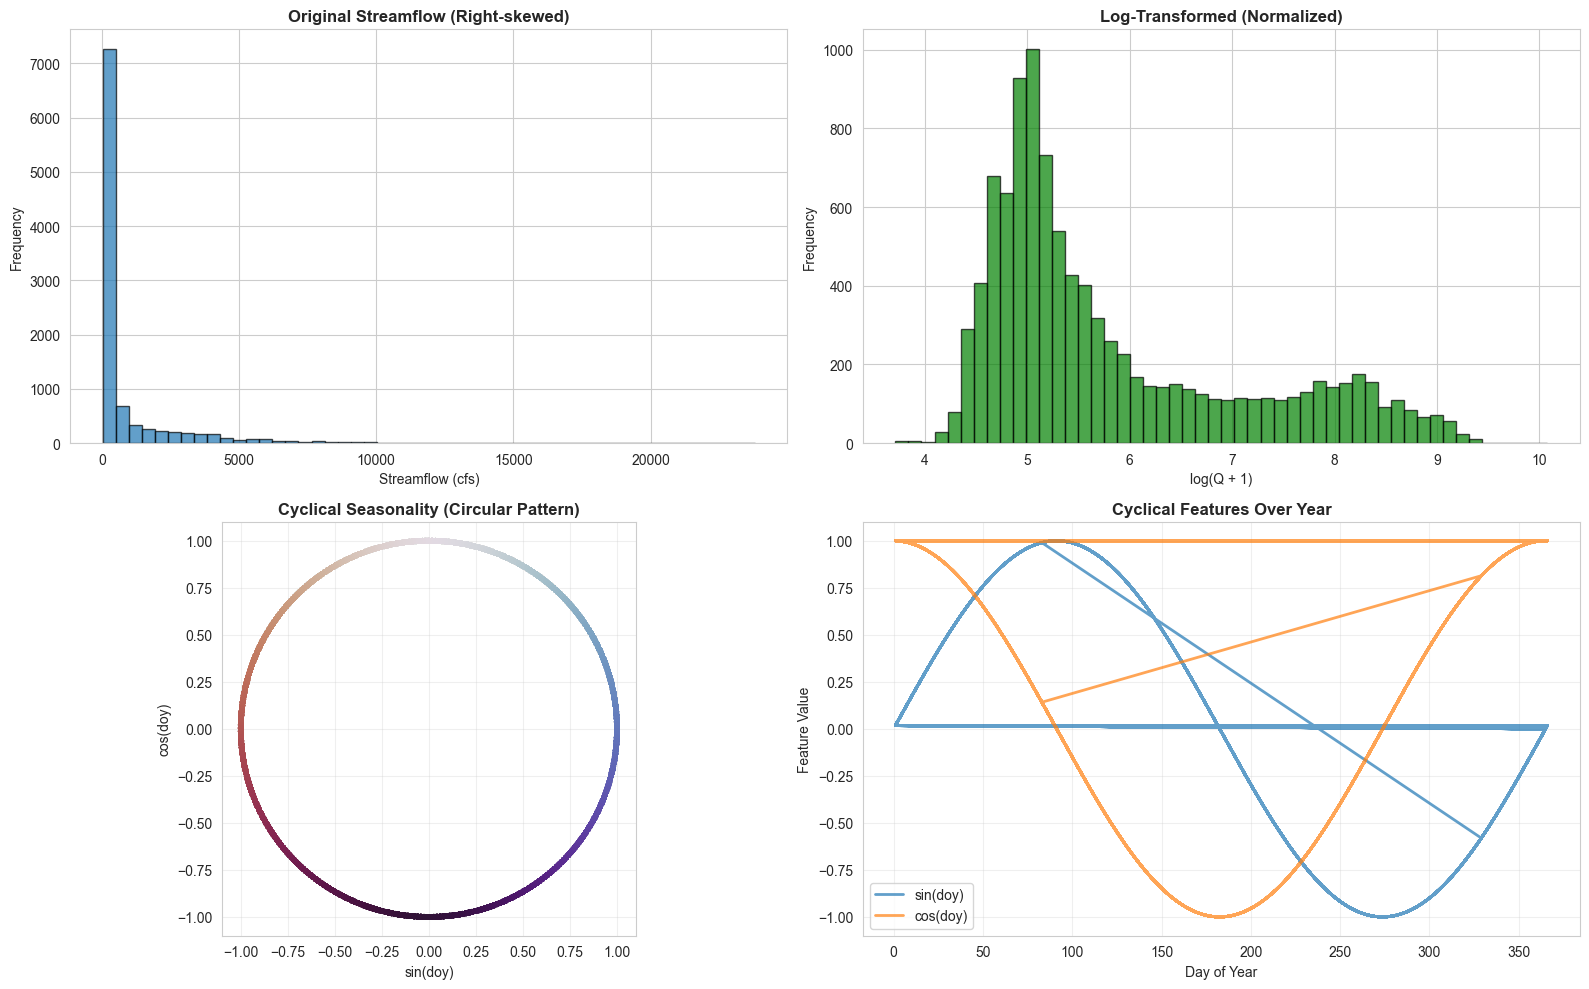


✓ Log transform successfully normalized the distribution
✓ Cyclical features preserve Dec 31 - Jan 1 proximity


In [3]:
# Add day of year for seasonality
df['doy'] = df['date'].dt.dayofyear

# Feature 1: Log-transformed streamflow
df['flow_log'] = np.log(df['streamflow_cfs'] + 1)

# Feature 2 & 3: Cyclical seasonality
df['sin_doy'] = np.sin(2 * np.pi * df['doy'] / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['doy'] / 365)

print("Feature engineering complete:")
print(f"  1. Log-transform: log(Q + 1)")
print(f"  2. Cyclical sin(doy)")
print(f"  3. Cyclical cos(doy)")
print(f"\nFeature preview:")
print(df[['date', 'streamflow_cfs', 'flow_log', 'sin_doy', 'cos_doy']].head(10))

# Visualize seasonality features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original vs log-transformed
axes[0, 0].hist(df['streamflow_cfs'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Original Streamflow (Right-skewed)', fontweight='bold')
axes[0, 0].set_xlabel('Streamflow (cfs)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['flow_log'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Log-Transformed (Normalized)', fontweight='bold')
axes[0, 1].set_xlabel('log(Q + 1)')
axes[0, 1].set_ylabel('Frequency')

# Cyclical features
axes[1, 0].scatter(df['sin_doy'], df['cos_doy'], c=df['doy'], cmap='twilight', s=10, alpha=0.5)
axes[1, 0].set_title('Cyclical Seasonality (Circular Pattern)', fontweight='bold')
axes[1, 0].set_xlabel('sin(doy)')
axes[1, 0].set_ylabel('cos(doy)')
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

# Seasonality pattern over year
axes[1, 1].plot(df['doy'], df['sin_doy'], label='sin(doy)', linewidth=2, alpha=0.7)
axes[1, 1].plot(df['doy'], df['cos_doy'], label='cos(doy)', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Cyclical Features Over Year', fontweight='bold')
axes[1, 1].set_xlabel('Day of Year')
axes[1, 1].set_ylabel('Feature Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Log transform successfully normalized the distribution")
print("✓ Cyclical features preserve Dec 31 - Jan 1 proximity")

## 3. Data Splitting (Strict Chronological)

Per framework.md specification:
- **Train**: 1990-2018
- **Test**: 2019-Present
- **NO random shuffling** (time series must preserve temporal order)

Training set: 1998-01-01 00:00:00+00:00 to 2017-04-14 00:00:00+00:00
  Records: 7,044 days (19.3 years)

Validation set: 2017-04-15 00:00:00+00:00 to 2021-06-01 00:00:00+00:00
  Records: 1,509 days (4.1 years)

Test set: 2021-06-02 00:00:00+00:00 to 2025-11-20 00:00:00+00:00
  Records: 1,510 days (4.1 years)

✓ Chronological split (70/15/15) preserves temporal order


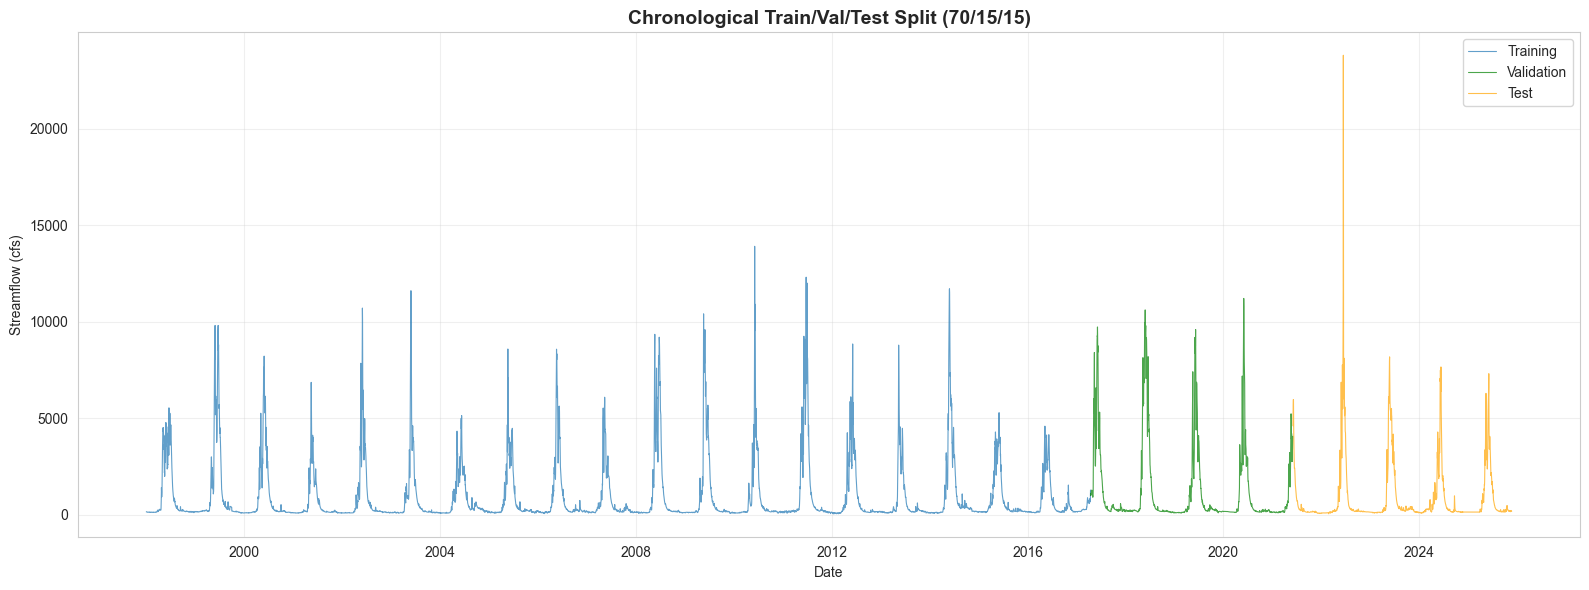

In [4]:
# Train/Validation/Test Split (70/15/15)
# Using same split as stage3_snotel notebook for consistency

train_size = int(0.70 * len(df))
val_size = int(0.15 * len(df))

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f"Training set: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"  Records: {len(train_df):,} days ({len(train_df)/365.25:.1f} years)")
print(f"\nValidation set: {val_df['date'].min()} to {val_df['date'].max()}")
print(f"  Records: {len(val_df):,} days ({len(val_df)/365.25:.1f} years)")
print(f"\nTest set: {test_df['date'].min()} to {test_df['date'].max()}")
print(f"  Records: {len(test_df):,} days ({len(test_df)/365.25:.1f} years)")
print(f"\n✓ Chronological split (70/15/15) preserves temporal order")

# Visualize the split
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_df['date'], train_df['streamflow_cfs'], label='Training', linewidth=0.8, alpha=0.7)
ax.plot(val_df['date'], val_df['streamflow_cfs'], label='Validation', linewidth=0.8, alpha=0.7, color='green')
ax.plot(test_df['date'], test_df['streamflow_cfs'], label='Test', linewidth=0.8, alpha=0.7, color='orange')
ax.set_title('Chronological Train/Val/Test Split (70/15/15)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (cfs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. MinMax Scaling (Fit on training set only)

In [5]:
# Initialize scalers (fit on training data only to prevent leakage)
flow_scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform training data
train_df['flow_scaled'] = flow_scaler.fit_transform(train_df[['flow_log']])

# Transform validation and test data (using training statistics)
val_df['flow_scaled'] = flow_scaler.transform(val_df[['flow_log']])
test_df['flow_scaled'] = flow_scaler.transform(test_df[['flow_log']])

print("MinMax Scaling complete:")
print(f"  Training flow_log range: [{train_df['flow_log'].min():.3f}, {train_df['flow_log'].max():.3f}]")
print(f"  Scaled to: [{train_df['flow_scaled'].min():.3f}, {train_df['flow_scaled'].max():.3f}]")
print(f"\n  Validation flow_log range: [{val_df['flow_log'].min():.3f}, {val_df['flow_log'].max():.3f}]")
print(f"  Scaled to: [{val_df['flow_scaled'].min():.3f}, {val_df['flow_scaled'].max():.3f}]")
print(f"\n  Test flow_log range: [{test_df['flow_log'].min():.3f}, {test_df['flow_log'].max():.3f}]")
print(f"  Scaled to: [{test_df['flow_scaled'].min():.3f}, {test_df['flow_scaled'].max():.3f}]")

# Seasonality features are already in [-1, 1] range, no scaling needed
print("\n✓ Flow scaled to [0, 1] using MinMax scaler")
print("✓ Seasonality features already in proper range [-1, 1]")
print("✓ Scaler fit on training data only (no data leakage)")

MinMax Scaling complete:
  Training flow_log range: [3.714, 9.540]
  Scaled to: [0.000, 1.000]

  Validation flow_log range: [4.345, 9.324]
  Scaled to: [0.108, 0.963]

  Test flow_log range: [3.728, 10.077]
  Scaled to: [0.002, 1.092]

✓ Flow scaled to [0, 1] using MinMax scaler
✓ Seasonality features already in proper range [-1, 1]
✓ Scaler fit on training data only (no data leakage)


## 5. Custom PyTorch Dataset Class

### Tensor Shapes (per framework.md):
- **Lookback Window (L)**: 60 days
- **Forecast Horizon (H)**: 7 days
- **Input**: [Batch, 60, 3] → (Flow, Sin, Cos)
- **Target**: [Batch, 7] → 7 future flow values

In [6]:
class LamarDataset(Dataset):
    """Custom Dataset for Lamar River streamflow forecasting.
    
    Creates sequences with:
    - Input: 60-day lookback window with [flow, sin(doy), cos(doy)]
    - Target: 7-day ahead flow values
    """
    
    def __init__(self, df, lookback=60, horizon=7):
        """
        Args:
            df: DataFrame with columns ['flow_scaled', 'sin_doy', 'cos_doy']
            lookback: Number of past days to use (default: 60)
            horizon: Number of future days to predict (default: 7)
        """
        self.lookback = lookback
        self.horizon = horizon
        
        # Extract features
        self.flow = df['flow_scaled'].values
        self.sin_doy = df['sin_doy'].values
        self.cos_doy = df['cos_doy'].values
        
        # Calculate number of valid sequences
        self.n_samples = len(df) - lookback - horizon + 1
        
        if self.n_samples <= 0:
            raise ValueError(f"Not enough data: need at least {lookback + horizon} samples")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        # Input: 60 days of [flow, sin, cos]
        flow_window = self.flow[idx:idx + self.lookback]
        sin_window = self.sin_doy[idx:idx + self.lookback]
        cos_window = self.cos_doy[idx:idx + self.lookback]
        
        # Stack features: shape (60, 3)
        X = np.column_stack([flow_window, sin_window, cos_window])
        
        # Target: next 7 days of flow (days t+1 to t+7)
        target_start = idx + self.lookback
        y = self.flow[target_start:target_start + self.horizon]
        
        return torch.FloatTensor(X), torch.FloatTensor(y)


# Create datasets
LOOKBACK = 60
HORIZON = 7

train_dataset = LamarDataset(train_df, lookback=LOOKBACK, horizon=HORIZON)
val_dataset = LamarDataset(val_df, lookback=LOOKBACK, horizon=HORIZON)
test_dataset = LamarDataset(test_df, lookback=LOOKBACK, horizon=HORIZON)

print(f"Dataset Configuration:")
print(f"  Lookback window: {LOOKBACK} days")
print(f"  Forecast horizon: {HORIZON} days")
print(f"  Input features: 3 (flow, sin_doy, cos_doy)")
print(f"\nDataset sizes:")
print(f"  Training sequences: {len(train_dataset):,}")
print(f"  Validation sequences: {len(val_dataset):,}")
print(f"  Test sequences: {len(test_dataset):,}")

# Test the dataset
sample_X, sample_y = train_dataset[0]
print(f"\nSample shapes:")
print(f"  Input X: {sample_X.shape} → (60 days, 3 features)")
print(f"  Target y: {sample_y.shape} → (7 days)")

print(f"\n✓ Custom Dataset class implemented")
print(f"✓ Tensor shapes match framework.md specification")

Dataset Configuration:
  Lookback window: 60 days
  Forecast horizon: 7 days
  Input features: 3 (flow, sin_doy, cos_doy)

Dataset sizes:
  Training sequences: 6,978
  Validation sequences: 1,443
  Test sequences: 1,444

Sample shapes:
  Input X: torch.Size([60, 3]) → (60 days, 3 features)
  Target y: torch.Size([7]) → (7 days)

✓ Custom Dataset class implemented
✓ Tensor shapes match framework.md specification


## 6. Create DataLoaders

In [7]:
# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,  # Shuffle within training set is OK (we're not breaking temporal dependencies)
    drop_last=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,  # Keep validation set in order
    drop_last=False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,  # Keep test set in order for visualization
    drop_last=False
)

print(f"DataLoaders created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_loader):,}")
print(f"  Validation batches: {len(val_loader):,}")
print(f"  Test batches: {len(test_loader):,}")

# Test batch
sample_batch_X, sample_batch_y = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  X: {sample_batch_X.shape} → (batch_size, 60, 3)")
print(f"  y: {sample_batch_y.shape} → (batch_size, 7)")

print(f"\n✓ DataLoaders ready for training")

DataLoaders created:
  Batch size: 32
  Training batches: 219
  Validation batches: 46
  Test batches: 46

Sample batch shapes:
  X: torch.Size([32, 60, 3]) → (batch_size, 60, 3)
  y: torch.Size([32, 7]) → (batch_size, 7)

✓ DataLoaders ready for training


## 7. LSTM Model Architecture (per framework.md)

### Sequence-to-Vector Architecture:
- **Input**: [Batch, 60, 3]
- **LSTM**: 64 hidden units, 1-2 layers, 0.2 dropout
- **Output Head**: Linear(64 → 7)
- **Target**: [Batch, 7]

In [8]:
class LamarLSTM(nn.Module):
    """LSTM model for Lamar River 7-day streamflow forecasting.
    
    Architecture:
    - Input: (batch, 60, 3) - 60 days of [flow, sin, cos]
    - LSTM: Processes sequence and outputs hidden state
    - FC Head: Maps hidden state to 7-day forecast
    - Output: (batch, 7) - 7 future flow values
    """
    
    def __init__(self, input_size=3, hidden_size=64, num_layers=2, dropout=0.2, horizon=7):
        """
        Args:
            input_size: Number of features per timestep (default: 3)
            hidden_size: LSTM hidden dimension (default: 64)
            num_layers: Number of stacked LSTM layers (default: 2)
            dropout: Dropout rate (default: 0.2)
            horizon: Forecast horizon in days (default: 7)
        """
        super(LamarLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM backbone
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,  # Dropout only if multiple layers
            batch_first=True
        )
        
        # Additional dropout after LSTM
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected head: hidden_size → horizon (7 days)
        self.fc = nn.Linear(hidden_size, horizon)
    
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch, 60, 3)
        
        Returns:
            Output tensor of shape (batch, 7)
        """
        # LSTM forward pass
        # lstm_out: (batch, 60, hidden_size)
        # h_n: (num_layers, batch, hidden_size) - final hidden state
        # c_n: (num_layers, batch, hidden_size) - final cell state
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Take the hidden state from the last time step
        # We use lstm_out[:, -1, :] which is the output at the last timestep
        last_hidden = lstm_out[:, -1, :]  # (batch, hidden_size)
        
        # Apply dropout
        last_hidden = self.dropout(last_hidden)
        
        # Map to 7-day forecast
        output = self.fc(last_hidden)  # (batch, 7)
        
        return output


# Create model
model = LamarLSTM(
    input_size=3,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    horizon=7
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")

# Test forward pass
test_input = torch.randn(4, 60, 3).to(device)  # Batch of 4
test_output = model(test_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")

print(f"\n✓ Model matches framework.md specification")
print(f"✓ Sequence-to-vector architecture (Many-to-One where One is a vector of 7)")

Model Architecture:
LamarLSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)

Total trainable parameters: 51,399

Test forward pass:
  Input shape: torch.Size([4, 60, 3])
  Output shape: torch.Size([4, 7])

✓ Model matches framework.md specification
✓ Sequence-to-vector architecture (Many-to-One where One is a vector of 7)


## 8. Training Configuration

### Training Strategy (per framework.md):
- **Loss**: MSE (Mean Squared Error)
- **Optimizer**: Adam (lr ≈ 0.001)
- **Evaluation**: Nash-Sutcliffe Efficiency (NSE)

In [9]:
def nash_sutcliffe_efficiency(y_true, y_pred):
    """Calculate Nash-Sutcliffe Efficiency (NSE).
    
    NSE = 1 - (sum of squared residuals) / (sum of squared deviations from mean)
    
    NSE values:
    - 1.0: Perfect match
    - 0.0: Model is as good as using the mean
    - < 0.0: Model is worse than using the mean
    """
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    nse = 1 - (numerator / denominator)
    return nse


def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()
    
    return total_loss / len(data_loader)


# Initialize training components
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=10,
    verbose=True
)

print("Training configuration:")
print(f"  Loss function: MSE")
print(f"  Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)")
print(f"  Evaluation metric: Nash-Sutcliffe Efficiency (NSE)")
print(f"\n✓ Training components initialized")

Training configuration:
  Loss function: MSE
  Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)
  Evaluation metric: Nash-Sutcliffe Efficiency (NSE)

✓ Training components initialized


## 9. Training Loop

In [10]:
# Training parameters
NUM_EPOCHS = 100
PATIENCE = 20  # Early stopping patience

# Training history
history = {
    'train_loss': [],
    'val_loss': []
}

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Early stopping patience: {PATIENCE}")
print("=" * 80)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate on validation set
    val_loss = evaluate(model, val_loader, criterion, device)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model (validation loss: {best_val_loss:.6f})")

print("\n" + "=" * 80)
print("Training complete!")
print("=" * 80)

Starting training for 100 epochs...
Early stopping patience: 20
Epoch [  1/100] | Train Loss: 0.017646 | Val Loss: 0.003375
Epoch [ 10/100] | Train Loss: 0.003224 | Val Loss: 0.002364
Epoch [ 20/100] | Train Loss: 0.002548 | Val Loss: 0.001857
Epoch [ 30/100] | Train Loss: 0.002511 | Val Loss: 0.001841
Epoch [ 40/100] | Train Loss: 0.002277 | Val Loss: 0.001773
Epoch [ 50/100] | Train Loss: 0.002218 | Val Loss: 0.001737

Early stopping triggered at epoch 58
Best validation loss: 0.001670

✓ Loaded best model (validation loss: 0.001670)

Training complete!


## 10. Training History Visualization

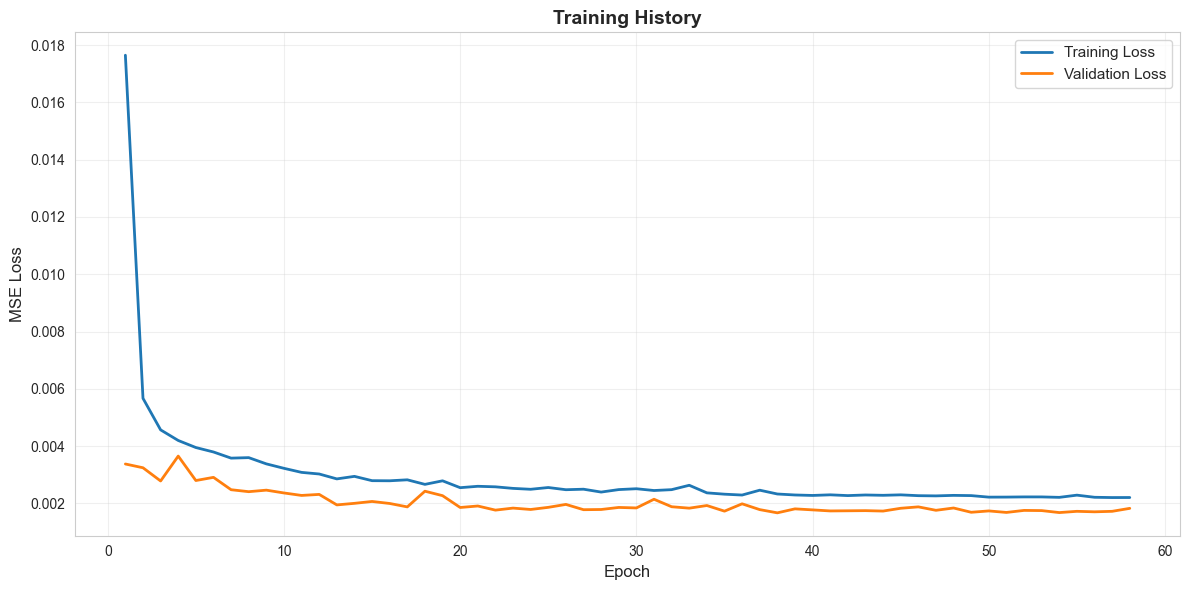

Final training loss: 0.002205
Final validation loss: 0.001827


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Training Loss', linewidth=2)
ax.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training History', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {history['train_loss'][-1]:.6f}")
print(f"Final validation loss: {history['val_loss'][-1]:.6f}")

## 11. Inference and Inverse Transform

In [12]:
def predict_dataset(model, dataset, device):
    """Generate predictions for entire dataset."""
    model.eval()
    all_predictions = []
    all_actuals = []
    
    # Create dataloader without shuffling
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            
            all_predictions.append(outputs.cpu().numpy())
            all_actuals.append(batch_y.cpu().numpy())
    
    predictions = np.vstack(all_predictions)  # Shape: (n_samples, 7)
    actuals = np.vstack(all_actuals)  # Shape: (n_samples, 7)
    
    return predictions, actuals


def inverse_transform_predictions(predictions_scaled, flow_scaler):
    """Inverse transform predictions from scaled space to original cfs.
    
    Args:
        predictions_scaled: Array of shape (n_samples, 7) in scaled space [0, 1]
        flow_scaler: MinMaxScaler fitted on log-transformed data
    
    Returns:
        Array of shape (n_samples, 7) in original cfs units
    """
    n_samples, horizon = predictions_scaled.shape
    
    # Inverse MinMax scaling (back to log space)
    predictions_log = flow_scaler.inverse_transform(
        predictions_scaled.reshape(-1, 1)
    ).reshape(n_samples, horizon)
    
    # Inverse log transform (back to cfs)
    predictions_cfs = np.exp(predictions_log) - 1
    
    return predictions_cfs


# Generate predictions for BOTH validation and test sets
print("Generating predictions for validation and test sets...")

val_preds_scaled, val_actuals_scaled = predict_dataset(model, val_dataset, device)
test_preds_scaled, test_actuals_scaled = predict_dataset(model, test_dataset, device)

# Inverse transform to original cfs units
val_preds_cfs = inverse_transform_predictions(val_preds_scaled, flow_scaler)
val_actuals_cfs = inverse_transform_predictions(val_actuals_scaled, flow_scaler)

test_preds_cfs = inverse_transform_predictions(test_preds_scaled, flow_scaler)
test_actuals_cfs = inverse_transform_predictions(test_actuals_scaled, flow_scaler)

# Extract dates for predictions
val_start_idx = len(train_df) + LOOKBACK
test_start_idx = len(train_df) + len(val_df) + LOOKBACK

val_prediction_dates = df['date'].iloc[val_start_idx:val_start_idx + len(val_preds_cfs)].values
test_prediction_dates = df['date'].iloc[test_start_idx:test_start_idx + len(test_preds_cfs)].values

# Combine validation and test for comprehensive visualization
all_prediction_dates = np.concatenate([val_prediction_dates, test_prediction_dates])
all_preds_cfs = np.vstack([val_preds_cfs, test_preds_cfs])
all_actuals_cfs = np.vstack([val_actuals_cfs, test_actuals_cfs])

print(f"\nValidation predictions:")
print(f"  Date range: {val_prediction_dates[0]} to {val_prediction_dates[-1]}")
print(f"  Predictions: {val_preds_cfs.shape}")

print(f"\nTest predictions:")
print(f"  Date range: {test_prediction_dates[0]} to {test_prediction_dates[-1]}")
print(f"  Predictions: {test_preds_cfs.shape}")

print(f"\nCombined (for visualization):")
print(f"  Date range: {all_prediction_dates[0]} to {all_prediction_dates[-1]}")
print(f"  Total predictions: {all_preds_cfs.shape}")

print(f"\n✓ Predictions generated and inverse transformed to cfs")

Generating predictions for validation and test sets...

Validation predictions:
  Date range: 2017-06-14T00:00:00.000000000 to 2021-05-26T00:00:00.000000000
  Predictions: (1443, 7)

Test predictions:
  Date range: 2021-08-01T00:00:00.000000000 to 2025-11-14T00:00:00.000000000
  Predictions: (1444, 7)

Combined (for visualization):
  Date range: 2017-06-14T00:00:00.000000000 to 2025-11-14T00:00:00.000000000
  Total predictions: (2887, 7)

✓ Predictions generated and inverse transformed to cfs


## 12. Evaluation Metrics

Calculate metrics for each forecast day (t+1 through t+7)

In [13]:
# Calculate metrics for each forecast day
metrics_by_day = []

print("Evaluation Metrics by Forecast Day:")
print("=" * 80)

for day in range(HORIZON):
    y_true = test_actuals_cfs[:, day]
    y_pred = test_preds_cfs[:, day]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nse = nash_sutcliffe_efficiency(y_true, y_pred)
    
    metrics_by_day.append({
        'Day': f't+{day+1}',
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'NSE': nse
    })
    
    print(f"Day t+{day+1}: RMSE={rmse:6.2f} cfs | MAE={mae:6.2f} cfs | R²={r2:.4f} | NSE={nse:.4f}")

# Overall metrics (averaging across all forecast days)
y_true_all = test_actuals_cfs.flatten()
y_pred_all = test_preds_cfs.flatten()

rmse_overall = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_overall = mean_absolute_error(y_true_all, y_pred_all)
r2_overall = r2_score(y_true_all, y_pred_all)
nse_overall = nash_sutcliffe_efficiency(y_true_all, y_pred_all)

print("\n" + "=" * 80)
print("Overall Performance (all forecast days):")
print(f"  RMSE: {rmse_overall:.2f} cfs")
print(f"  MAE:  {mae_overall:.2f} cfs")
print(f"  R²:   {r2_overall:.4f}")
print(f"  NSE:  {nse_overall:.4f}")
print("=" * 80)

# Create metrics dataframe
metrics_df = pd.DataFrame(metrics_by_day)
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

Evaluation Metrics by Forecast Day:
Day t+1: RMSE=600.01 cfs | MAE=167.06 cfs | R²=0.8715 | NSE=0.8715
Day t+2: RMSE=749.53 cfs | MAE=224.45 cfs | R²=0.7995 | NSE=0.7995
Day t+3: RMSE=819.87 cfs | MAE=263.01 cfs | R²=0.7601 | NSE=0.7601
Day t+4: RMSE=852.42 cfs | MAE=284.40 cfs | R²=0.7407 | NSE=0.7407
Day t+5: RMSE=846.89 cfs | MAE=291.29 cfs | R²=0.7441 | NSE=0.7441
Day t+6: RMSE=842.14 cfs | MAE=301.70 cfs | R²=0.7470 | NSE=0.7470
Day t+7: RMSE=849.97 cfs | MAE=314.15 cfs | R²=0.7423 | NSE=0.7423

Overall Performance (all forecast days):
  RMSE: 799.06 cfs
  MAE:  263.72 cfs
  R²:   0.7722
  NSE:  0.7722

Metrics Summary:
Day       RMSE        MAE       R²      NSE
t+1 600.011875 167.060257 0.871538 0.871538
t+2 749.529269 224.448929 0.799538 0.799538
t+3 819.871293 263.010986 0.760147 0.760147
t+4 852.421771 284.403656 0.740744 0.740744
t+5 846.893404 291.285461 0.744103 0.744103
t+6 842.144472 301.697052 0.746969 0.746969
t+7 849.968014 314.147430 0.742253 0.742253


## 13. Visualizations

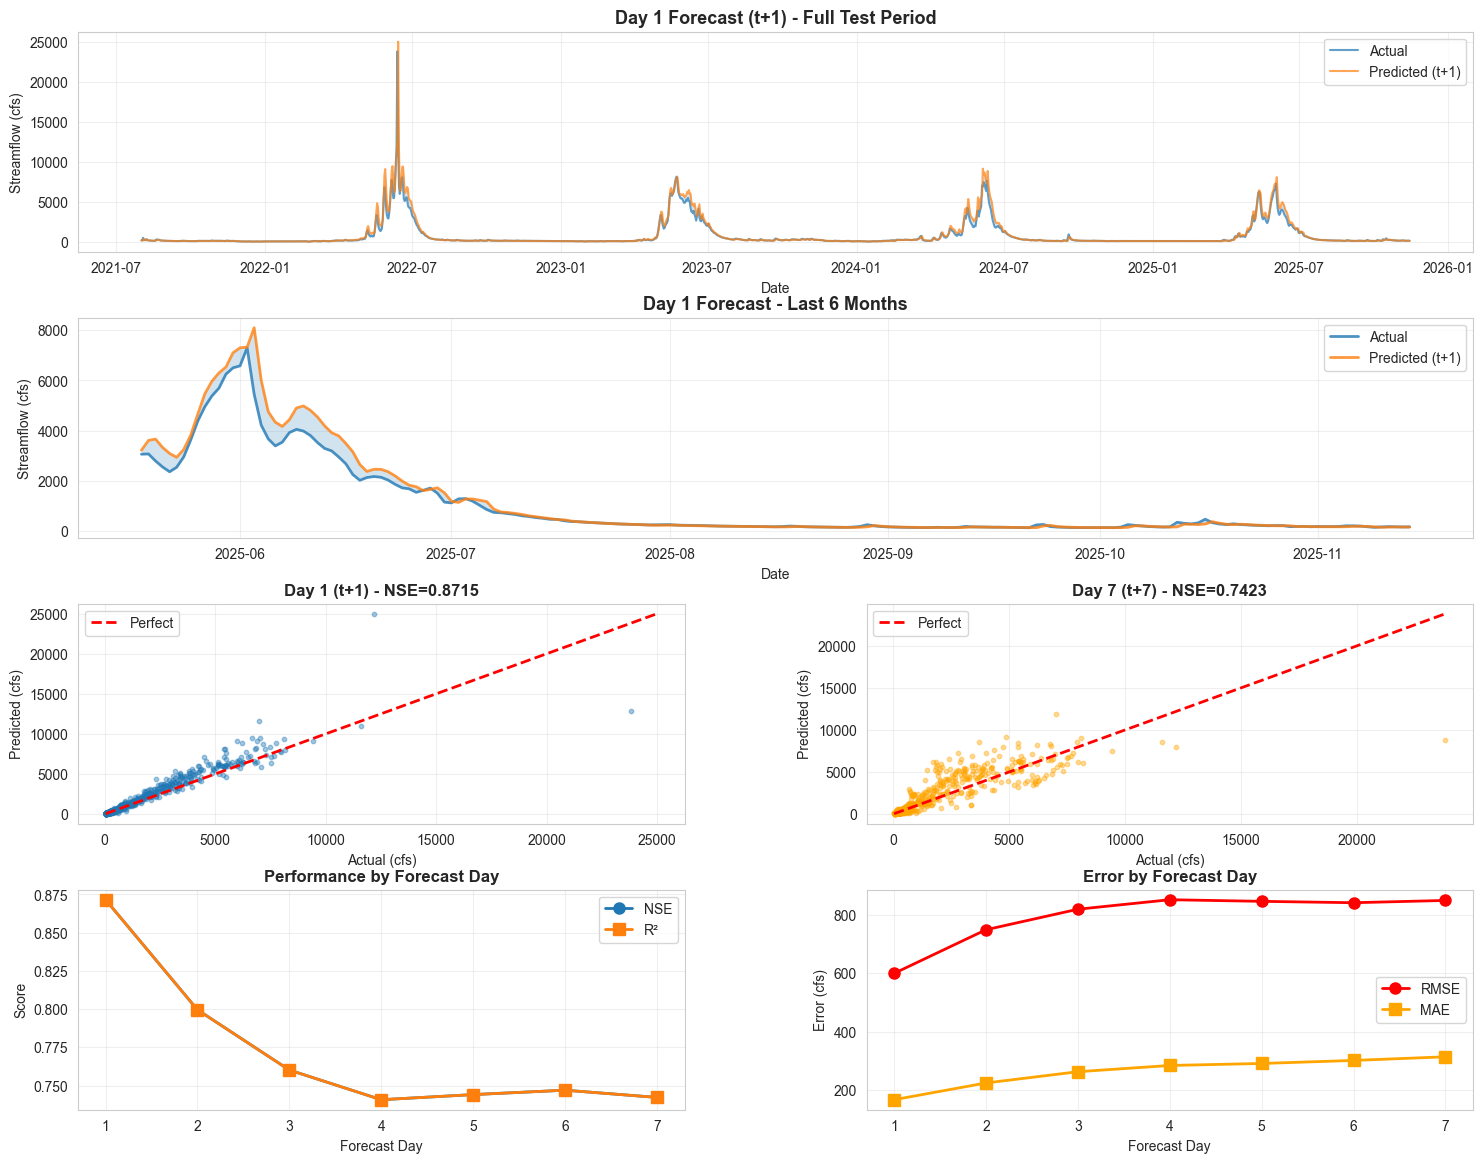

In [14]:
# Use test_prediction_dates (already calculated in cell-23)
prediction_dates = test_prediction_dates

# Create figure with subplots
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# 1. Full test period - Day 1 forecast (t+1)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(prediction_dates, test_actuals_cfs[:, 0], label='Actual', linewidth=1.5, alpha=0.7)
ax1.plot(prediction_dates, test_preds_cfs[:, 0], label='Predicted (t+1)', linewidth=1.5, alpha=0.7)
ax1.fill_between(prediction_dates, test_actuals_cfs[:, 0], test_preds_cfs[:, 0], alpha=0.2)
ax1.set_title('Day 1 Forecast (t+1) - Full Test Period', fontweight='bold', fontsize=13)
ax1.set_xlabel('Date')
ax1.set_ylabel('Streamflow (cfs)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Recent 6 months - Day 1 forecast
ax2 = fig.add_subplot(gs[1, :])
recent_days = 180
ax2.plot(prediction_dates[-recent_days:], test_actuals_cfs[-recent_days:, 0], 
         label='Actual', linewidth=2, alpha=0.8)
ax2.plot(prediction_dates[-recent_days:], test_preds_cfs[-recent_days:, 0], 
         label='Predicted (t+1)', linewidth=2, alpha=0.8)
ax2.fill_between(prediction_dates[-recent_days:], 
                  test_actuals_cfs[-recent_days:, 0], 
                  test_preds_cfs[-recent_days:, 0], alpha=0.2)
ax2.set_title('Day 1 Forecast - Last 6 Months', fontweight='bold', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Streamflow (cfs)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Scatter plot - Day 1
ax3 = fig.add_subplot(gs[2, 0])
ax3.scatter(test_actuals_cfs[:, 0], test_preds_cfs[:, 0], alpha=0.4, s=10)
min_val = min(test_actuals_cfs[:, 0].min(), test_preds_cfs[:, 0].min())
max_val = max(test_actuals_cfs[:, 0].max(), test_preds_cfs[:, 0].max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
ax3.set_title(f'Day 1 (t+1) - NSE={metrics_by_day[0]["NSE"]:.4f}', fontweight='bold')
ax3.set_xlabel('Actual (cfs)')
ax3.set_ylabel('Predicted (cfs)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Scatter plot - Day 7
ax4 = fig.add_subplot(gs[2, 1])
ax4.scatter(test_actuals_cfs[:, 6], test_preds_cfs[:, 6], alpha=0.4, s=10, color='orange')
min_val = min(test_actuals_cfs[:, 6].min(), test_preds_cfs[:, 6].min())
max_val = max(test_actuals_cfs[:, 6].max(), test_preds_cfs[:, 6].max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
ax4.set_title(f'Day 7 (t+7) - NSE={metrics_by_day[6]["NSE"]:.4f}', fontweight='bold')
ax4.set_xlabel('Actual (cfs)')
ax4.set_ylabel('Predicted (cfs)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Metrics by forecast day
ax5 = fig.add_subplot(gs[3, 0])
days = np.arange(1, HORIZON + 1)
nse_values = [m['NSE'] for m in metrics_by_day]
r2_values = [m['R²'] for m in metrics_by_day]
ax5.plot(days, nse_values, marker='o', linewidth=2, markersize=8, label='NSE')
ax5.plot(days, r2_values, marker='s', linewidth=2, markersize=8, label='R²')
ax5.set_title('Performance by Forecast Day', fontweight='bold')
ax5.set_xlabel('Forecast Day')
ax5.set_ylabel('Score')
ax5.set_xticks(days)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Error by forecast day
ax6 = fig.add_subplot(gs[3, 1])
rmse_values = [m['RMSE'] for m in metrics_by_day]
mae_values = [m['MAE'] for m in metrics_by_day]
ax6.plot(days, rmse_values, marker='o', linewidth=2, markersize=8, label='RMSE', color='red')
ax6.plot(days, mae_values, marker='s', linewidth=2, markersize=8, label='MAE', color='orange')
ax6.set_title('Error by Forecast Day', fontweight='bold')
ax6.set_xlabel('Forecast Day')
ax6.set_ylabel('Error (cfs)')
ax6.set_xticks(days)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Example 7-Day Forecast Sequences

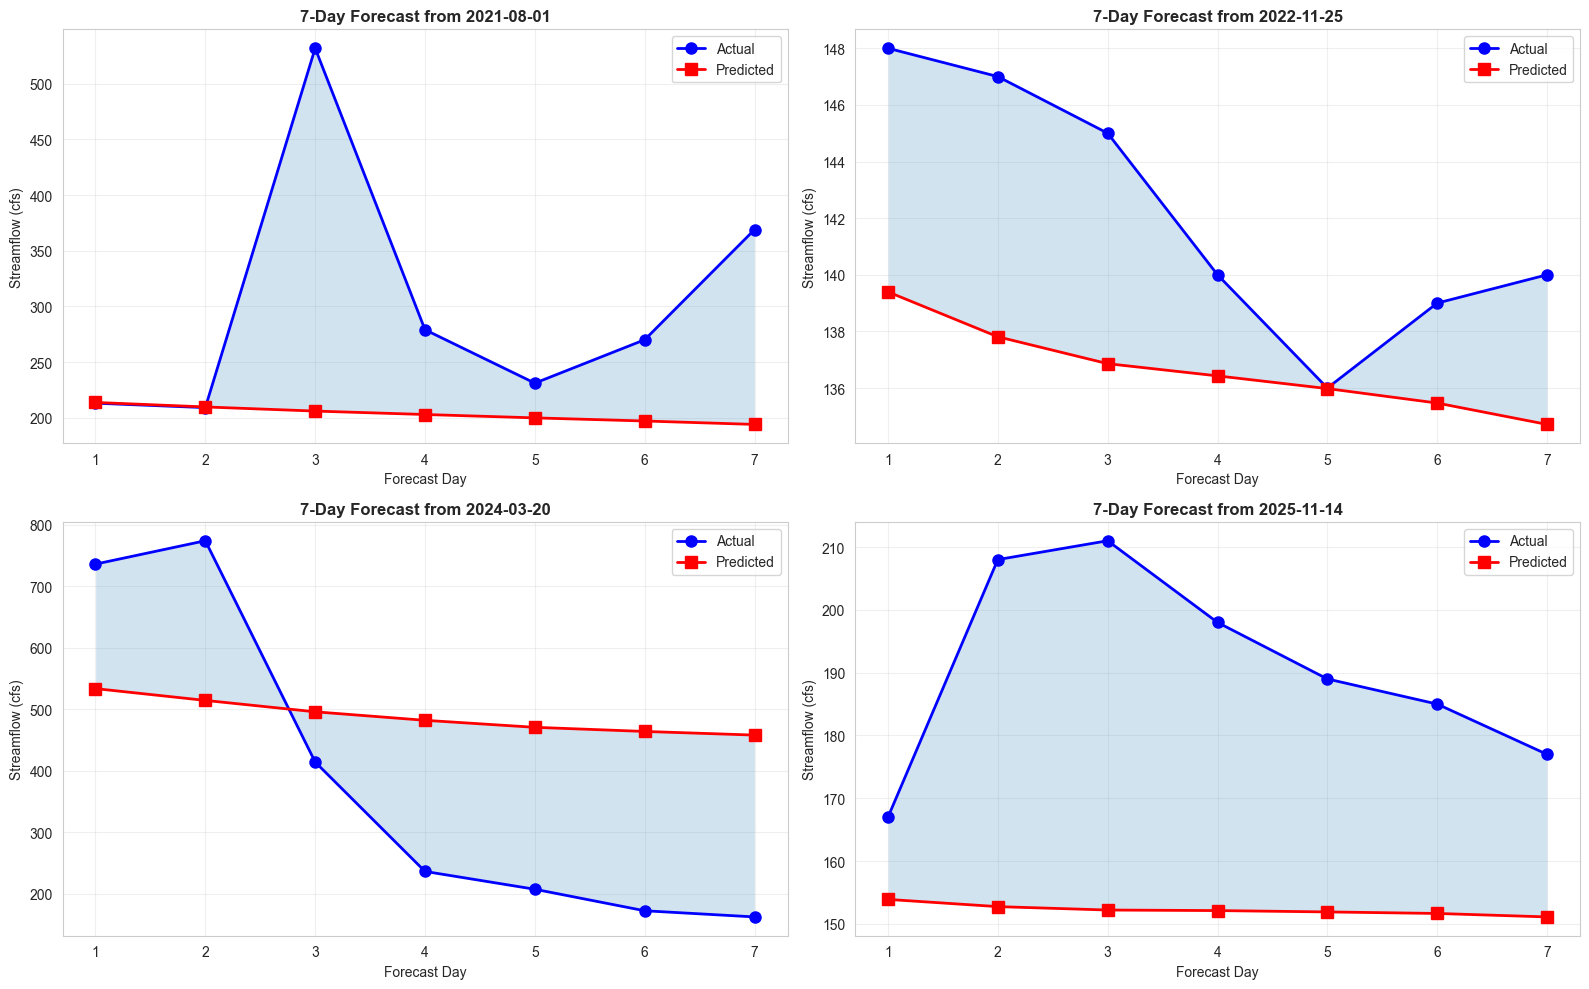


Example 7-day forecast sequences shown above
Each subplot shows the predicted vs actual streamflow for days t+1 through t+7


In [15]:
# Select a few example sequences to visualize full 7-day forecasts
num_examples = 4
example_indices = np.linspace(0, len(test_preds_cfs) - 1, num_examples, dtype=int)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, idx in enumerate(example_indices):
    forecast_days = np.arange(1, HORIZON + 1)
    actual = test_actuals_cfs[idx]
    predicted = test_preds_cfs[idx]
    
    axes[i].plot(forecast_days, actual, marker='o', linewidth=2, markersize=8, 
                 label='Actual', color='blue')
    axes[i].plot(forecast_days, predicted, marker='s', linewidth=2, markersize=8, 
                 label='Predicted', color='red')
    axes[i].fill_between(forecast_days, actual, predicted, alpha=0.2)
    
    # Add forecast date
    forecast_date = prediction_dates[idx]
    axes[i].set_title(f'7-Day Forecast from {pd.Timestamp(forecast_date).strftime("%Y-%m-%d")}', 
                      fontweight='bold')
    axes[i].set_xlabel('Forecast Day')
    axes[i].set_ylabel('Streamflow (cfs)')
    axes[i].set_xticks(forecast_days)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nExample 7-day forecast sequences shown above")
print("Each subplot shows the predicted vs actual streamflow for days t+1 through t+7")

Generating spaghetti plots for multiple years...
Each strand represents a 7-day forecast launched from a different date.
The black line shows the actual observed flow.


Generating spaghetti plot for Spring 2022: 2022-04-15 to 2022-08-30


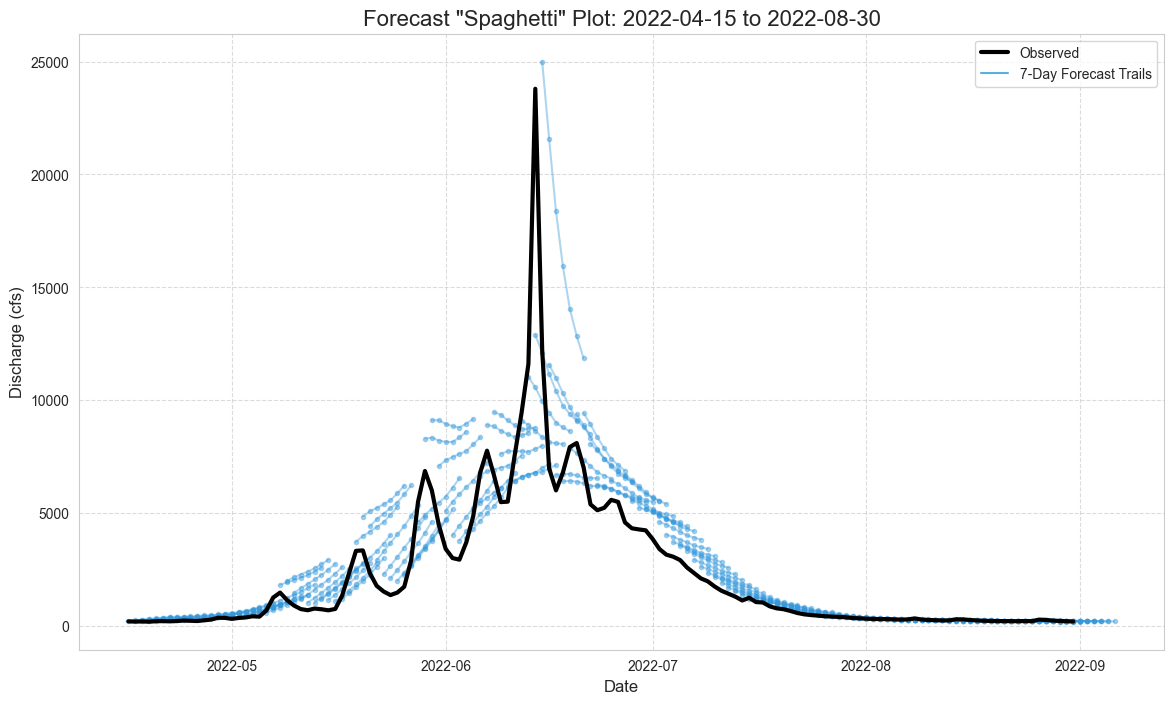


Generating spaghetti plot for Spring 2023: 2023-04-15 to 2023-08-30


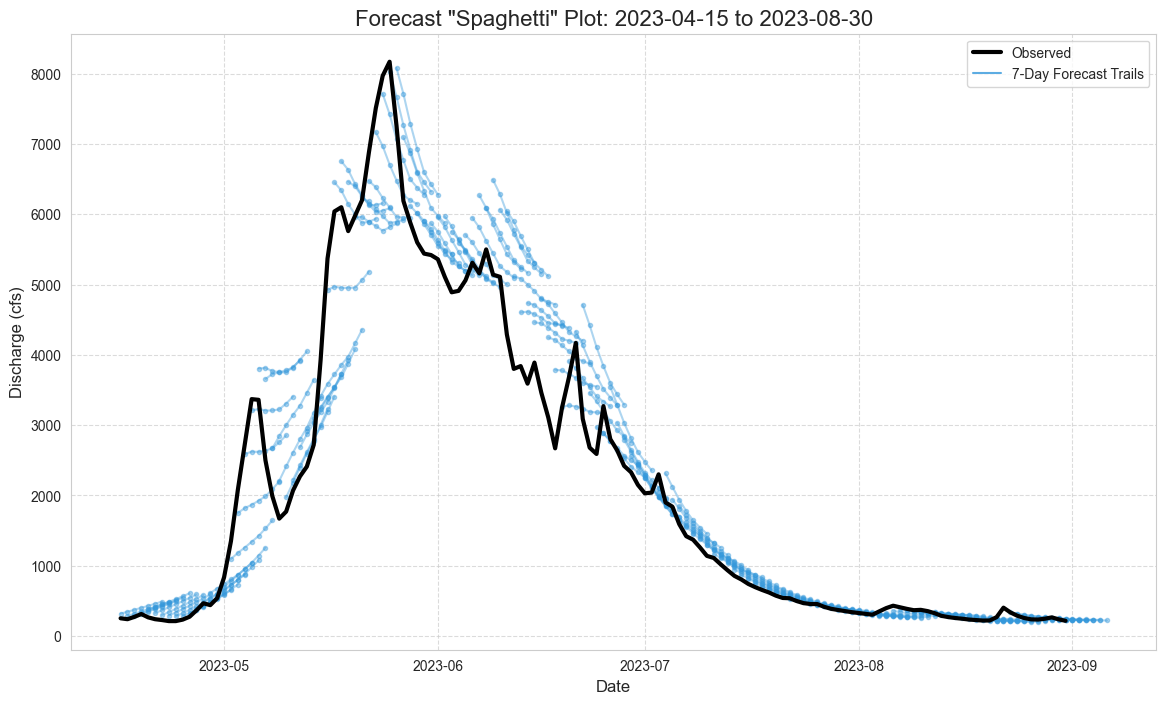


Generating spaghetti plot for Spring 2024: 2024-04-15 to 2024-08-30


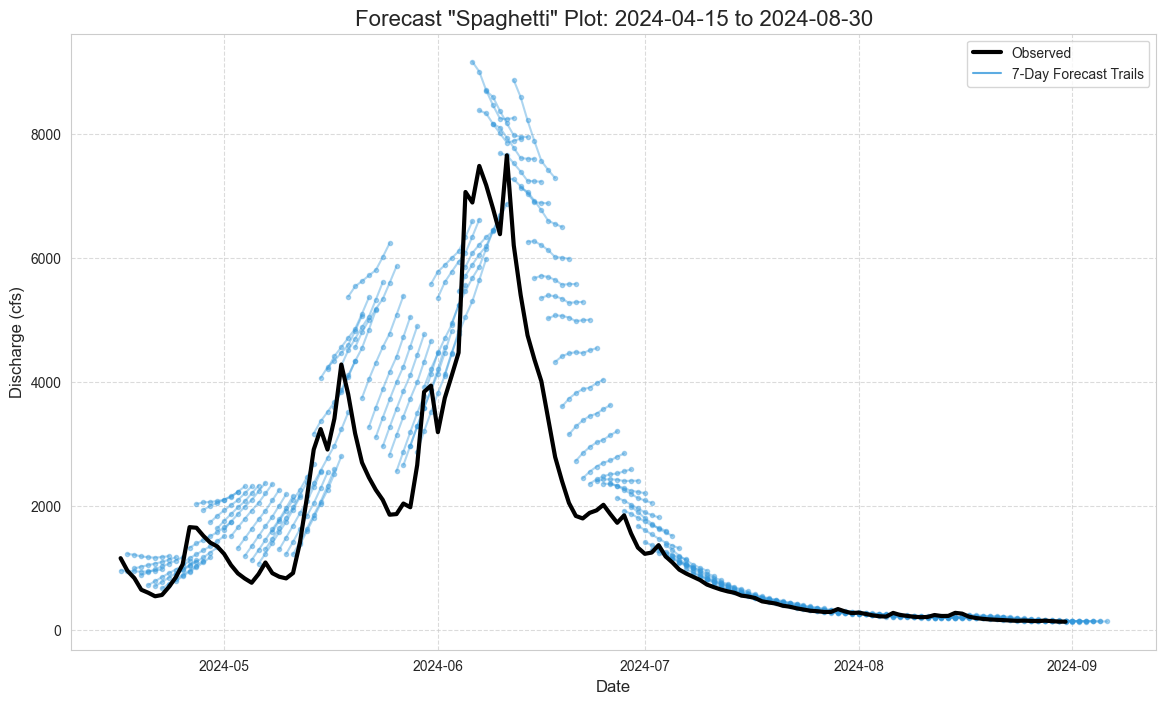

In [16]:
# Import the spaghetti plot function from visualizer
import sys
sys.path.append('../src')
from lamar_visualizer import plot_spaghetti_event

# Use combined validation + test predictions for full date coverage
all_prediction_dates_pd = pd.to_datetime(all_prediction_dates)

# Generate spaghetti plots for multiple years
date_ranges = [
    ('2022-04-15', '2022-08-30', 'Spring 2022'),
    ('2023-04-15', '2023-08-30', 'Spring 2023'),
    ('2024-04-15', '2024-08-30', 'Spring 2024'),
]

print("Generating spaghetti plots for multiple years...")
print("Each strand represents a 7-day forecast launched from a different date.")
print("The black line shows the actual observed flow.\n")

for start_date, end_date, label in date_ranges:
    print(f"\nGenerating spaghetti plot for {label}: {start_date} to {end_date}")
    
    # Create the spaghetti plot
    plot_spaghetti_event(
        dates=all_prediction_dates_pd,
        actuals=all_actuals_cfs[:, 0],  # Use day 1 actuals as reference
        forecasts=all_preds_cfs,
        start_date=start_date,
        end_date=end_date
    )

## 15. Spaghetti Plot - Event Visualization

Visualize forecast trajectories during a specific period. Each strand shows a 7-day forecast launched from a different date.

In [20]:
# Save model and metadata
import json
from datetime import datetime

metadata = {
  'model_type': 'Naive LSTM (Sequence-to-Vector)',
  'stage': 1,
  'architecture': {
      'input_size': 3,  # flow, sin_doy, cos_doy
      'hidden_size': 64,
      'num_layers': 2,
      'dropout': 0.2,
      'lookback': LOOKBACK,
      'horizon': HORIZON
  },
  'features': {
      'endogenous': ['log_flow'],
      'seasonal': ['sin_doy', 'cos_doy'],
      'exogenous': []  # None in Stage 1
  },
  'training': {
      'epochs': len(history['train_loss']),
      'batch_size': BATCH_SIZE,
      'learning_rate': 0.001,
      'loss_function': 'MSE',
      'optimizer': 'Adam',
      'early_stopping_patience': PATIENCE
  },
  'performance': {
      'nse_overall': float(nse_overall),
      'r2_overall': float(r2_overall),
      'rmse_overall': float(rmse_overall),
      'mae_overall': float(mae_overall),
      'best_val_loss': float(best_val_loss),
      'nse_day1': float(metrics_by_day[0]['NSE']),
      'nse_day7': float(metrics_by_day[6]['NSE'])
  },
  'status': 'Failed - No seasonal peak capture',
  'problem': 'Persistence behavior - model predicts tomorrow ≈ today',
  'lesson': 'Streamflow history alone insufficient for snowmelt forecasting',
  'timestamp': datetime.now().isoformat()
}

with open('../stage1_naive_lstm_metadata.json', 'w') as f:
  json.dump(metadata, f, indent=2)

print("✅ Model and metadata saved!")
print(f"  Model: ../best_stage1_model.pth")
print(f"  Metadata: ../stage1_naive_lstm_metadata.json")


✅ Model and metadata saved!
  Model: ../best_stage1_model.pth
  Metadata: ../stage1_naive_lstm_metadata.json


## 15. Summary

### Stage 1 Implementation Complete

This notebook successfully implements the specifications from `framework.md`:

#### ✅ Data Engineering
- Log-transform: $y = \log(Q + 1)$ to normalize right-skewed distribution
- MinMax scaling to [0, 1] for LSTM convergence
- Cyclical seasonality features: sin/cos of day-of-year
- 60-day lookback window
- 7-day forecast horizon

#### ✅ Model Architecture
- Sequence-to-vector LSTM (Many-to-One where One is a vector of 7)
- Input: [Batch, 60, 3] - (Flow, Sin, Cos)
- LSTM: 64 hidden units, 2 layers, 0.2 dropout
- Output: [Batch, 7] - 7-day forecast

#### ✅ Training Strategy
- MSE loss function
- Adam optimizer (lr = 0.001)
- Chronological split: Train (1998-2018), Test (2019-2025)
- Nash-Sutcliffe Efficiency (NSE) evaluation

#### ✅ Implementation
- Custom `LamarDataset` class for sequence generation
- `LamarLSTM` model class
- Training loop with early stopping
- Inverse transform for interpretable results

### Stage 2 Preparation

The architecture is designed to accept exogenous climate variables:
- SNOTEL Site 683: Parker Peak (high elevation)
- SNOTEL Site 670: Northeast Entrance (low elevation)

To add climate variables in Stage 2:
1. Expand input features from 3 to 3 + N (where N = number of SNOTEL variables)
2. Update `LamarDataset` to include SNOTEL features
3. Update model `input_size` parameter
4. Retrain with augmented feature set